Notebook for results

In [1]:
#Import libraries

#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp
import json

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
install_path_local2 = "/home/andress/pylabs/SCICoNE_lab/build2/"
temporary_outpath = './'
adatas_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)
sci2 = scicone.SCICoNE(install_path_local2, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/
Using binaries at /home/andress/pylabs/SCICoNE_lab/build2/


In [2]:
gr_annotations_df = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

In [3]:
adata = anndata.read_h5ad('/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas/adata_leiden.h5ad') 

gr_annotations = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

df_annotations = gr_annotations.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})

adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]


df_exp_annotations_sorted = df_exp_annotations.sort_values(by=['Chromosome', 'End'])


In [4]:
#SORT ADATA OBJECT (already sorted)

# Merge Chromosome and End information into adata.var
# adata.var = adata.var.merge(gr_annotations_df[['ensembl_gene_id', 'Chromosome', 'End']], 
#                             on='ensembl_gene_id', how='left')

# print(adata.var.columns)

# adata.var['Chromosome'] = adata.var['Chromosome'].astype(str)  # Convert Chromosome to string

# # Sort adata.var by Chromosome and End
# sorted_var = adata.var.sort_values(by=['Chromosome', 'End'])

# # Reorder adata.X columns based on the sorted var index
# adata = adata[:, sorted_var.index]

In [5]:
chr_var_names = dict()
for chromosome in df_exp_annotations_sorted['Chromosome'].unique():
    chr_var_names[chromosome] = df_exp_annotations_sorted.query(f' Chromosome=="{chromosome}" ')\
                                .sort_values('Start')['ensembl_gene_id'].values

# Load the JSON file as a dictionary
json_file_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/chromosome_stops.json'
with open(json_file_path, 'r') as file:
    chromosome_stops = json.load(file)

#sort the dictionary by values
chromosome_stops = {k: v for k, v in sorted(chromosome_stops.items(), key=lambda item: item[1])}
chromosome_stops = {np.str_(k): np.int64(v) for k, v in chromosome_stops.items()}

# Use chromosome_stops directly without further processing
#add 0 and final position
chromosome_stops_list = [np.int64(0)] + sorted(list(chromosome_stops.values())) + [np.int64(adata.shape[1]-1)]

print(chromosome_stops_list)


[np.int64(0), np.int64(218), np.int64(2859), np.int64(3508), np.int64(4457), np.int64(5335), np.int64(6090), np.int64(6370), np.int64(7179), np.int64(8215), np.int64(8612), np.int64(9783), np.int64(10119), np.int64(11024), np.int64(11571), np.int64(12091), np.int64(12519), np.int64(13423), np.int64(14172), np.int64(15474), np.int64(15845), np.int64(16110), np.int64(16505), np.int64(16700), np.int64(17151), np.int64(17151)]


In [6]:
# import matplotlib.pyplot as plt
# file_list = ['adata_clusters_median', 'adata_clusters_mean', 'adata_clusters_sum', 'clusters_mean_transformed',
#              'clusters_sum_transformed', 'clusters_median_transformed']
# # Initialize a dictionary to store results
# breakpoints_data = {}

# for cluster_file in file_list:
#     breakpoints_data[cluster_file] = []
#     for window_size in range(200, 800, 100):
#         try:
#             adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
#             data = adata.X
#             # Run SCICoNE analysis
#             matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}_{window_size}.png"
#             bps = sci.detect_breakpoints(data=data, window_size=window_size, threshold=3, input_breakpoints=chromosome_stops_list)
#             breakpoints_data[cluster_file].append((window_size, len(bps['segmented_regions'])))
#             scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
#                                                 chr_stops_dict=chromosome_stops,
#                                                 cbar_title='Normalized\n  counts', vmax=2, cluster=False)
#             plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
#             plt.close()

#             #Learn and save the tree plot
            
#             inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
#             inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

#             tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
#             #Render the tree plot using graphviz's render method

#             inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
#             print(f"Tree plot saved to {tree_plot_filename}.png")

#         except Exception as e:
#             print(f"Error processing {cluster_file} with window size {window_size}: {e}")
#             continue

# # Plot the results
# for cluster_file, data_points in breakpoints_data.items():
#     if data_points:
#         window_sizes, breakpoints_counts = zip(*data_points)
#         plt.figure(figsize=(8, 6))
#         plt.plot(window_sizes, breakpoints_counts, marker='o', label=cluster_file)
#         plt.title(f'Breakpoints Detected vs Window Size for {cluster_file}')
#         plt.xlabel('Window Size')
#         plt.ylabel('Number of Breakpoints Detected')
#         plt.legend()
#         plt.grid(True)
#         plt.show()
#         #save plots
#         plt.savefig(f"{temporary_outpath}/breakpoints_plot_{cluster_file}.png", dpi=300, bbox_inches='tight')



min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
n_regions: 26
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00248115
217, 219
216, 220
215, 221
214, 222
Adding 218: 0.248115
2858, 2860
2857, 2861
2856, 2862
2855, 2863
Adding 2859: 0.248115
3507, 3509
3506, 3510
3505, 3511
3504, 3512
Adding 3508: 0.248115
4456, 4458
4455, 4459
4454, 4460
4453, 4461
Adding 4457: 0.248115
5334, 5336
5333, 5337
5332, 5338
5331, 5339
Adding 5335: 0.248115
6089, 6091
6088, 6092
6087, 6093
6086, 6094
Adding 6090: 0.248115
6369, 6371
6368, 6372
6367, 6373
6366, 6374
Adding 6370: 0.248115
7178, 7180
7177, 7181
7176, 7182
7175, 7183
Adding 7179: 0.248115
8214, 8216
8213, 8217


no breakpoints are found within the interval: (16510,16514)
no breakpoints are found within the interval: (16592,16600)
no breakpoints are found within the interval: (16672,16683)


Index of the maximum 16575 is added to all_max_ids.
Index of the maximum 16589 is added to all_max_ids.
Index of the maximum 16582 is added to all_max_ids.
Index of the maximum 16665 is added to all_max_ids.
Index of the maximum 16669 is added to all_max_ids.
Found 37 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ordered segmented region sizes to file...
Segmented region sizes are written to file


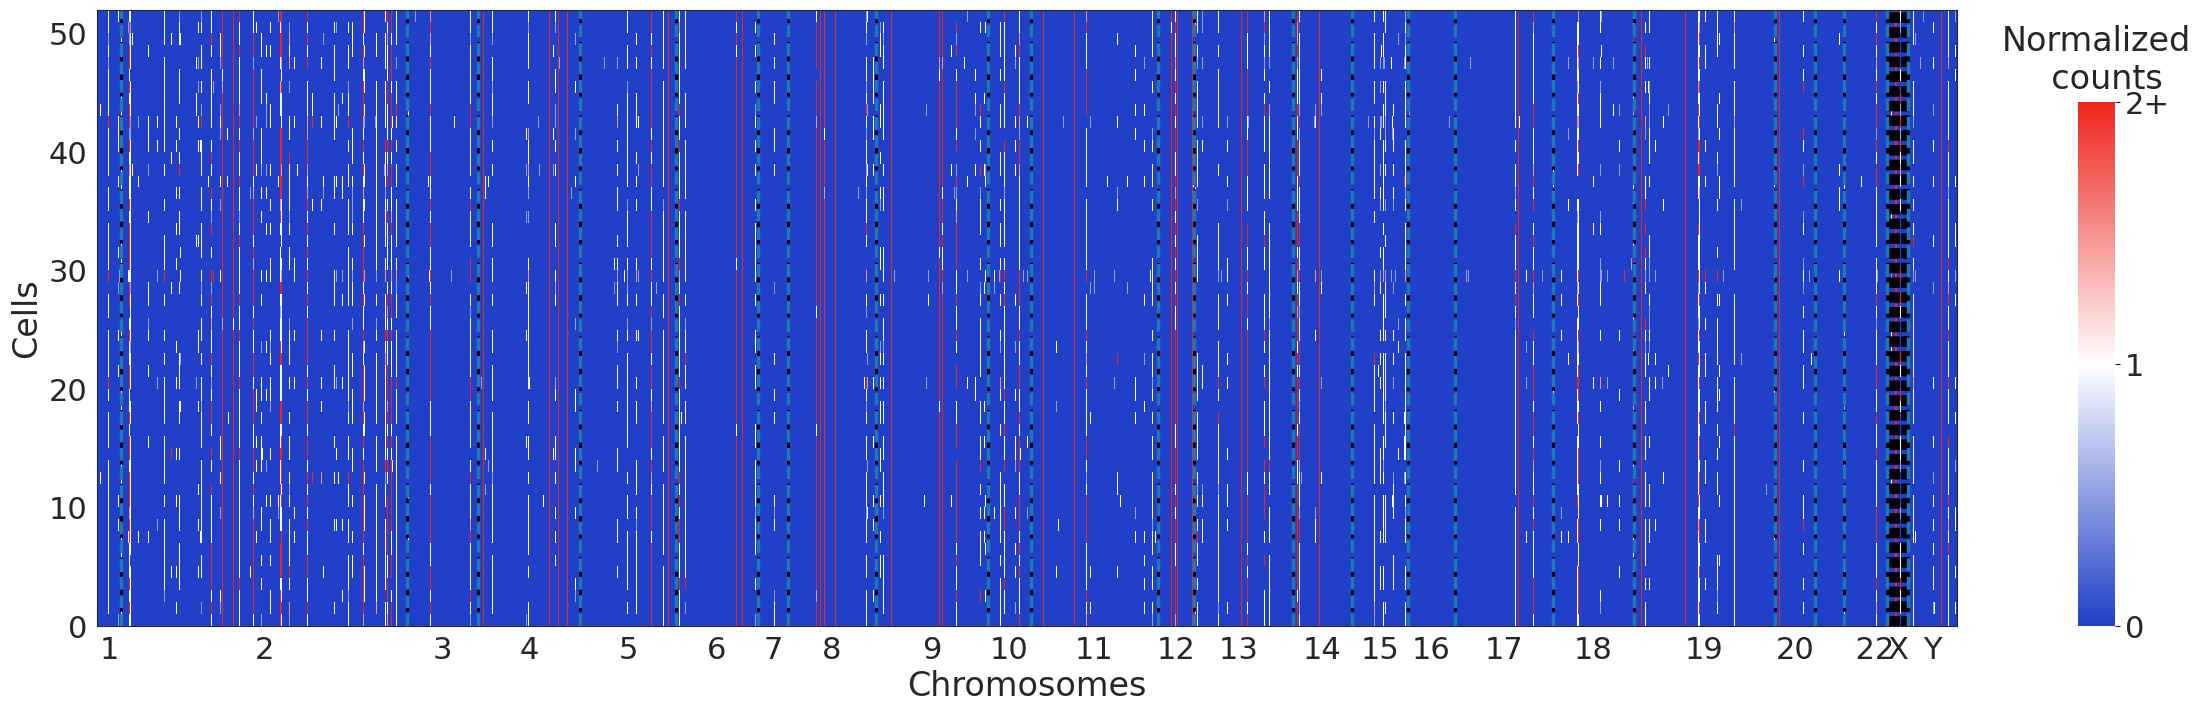

In [12]:

cluster_file = 'adata_clusters_median'
window_size = 5

#for a in ['Average', 'Sigmoid', 'Gaussian']:
try:
    adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
    data = adata.X
    # Run SCICoNE analysis
    matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}_{window_size}.png"
    bps = sci2.detect_breakpoints(data=data, window_size=window_size, threshold=3, input_breakpoints=chromosome_stops_list, use_zinb = True)
    #breakpoints_data[cluster_file].append((window_size, len(bps['segmented_regions'])))
    scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                        chr_stops_dict=chromosome_stops,
                                        cbar_title='Normalized\n  counts', vmax=2, cluster=False)
    plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
    plt.close()

    #Learn and save the tree plot
    
    # inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
    # inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

    # tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
    # #Render the tree plot using graphviz's render method

    # inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
    # # print(f"Tree plot saved to {tree_plot_filename}.png")


except Exception as e:
    print(f"Error processing {cluster_file} with window size {window_size}: {e}")


Condensing regions...
Done.
Learning cluster tree...
n_neighbours to be used: 5
Setting min_cluster_size to 1
Finding 5 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.010777473449707031 seconds
Jaccard graph constructed in 0.0014407634735107422 seconds
Wrote graph to binary file in 0.0018923282623291016 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.803672
Louvain completed 21 runs in 0.07523965835571289 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.36333751678466797 seconds
Found 7 clusters.
Cluster sizes: [9. 8. 8. 8. 7. 7. 5.]
Creating ./rep2_try0_PYSCICONETREETEMP_PYSCICONETEMP...Creating ./rep3_try0_PYSCICONETREETEMP_PYSCICONETEMP...Creating ./rep0_try0_PYSCICONETREETEMP_PYSCICONETEMP...
Creating ./rep1_try0_PYSCICONETREETEMP_PYSCICONETEMP...


Created ./rep2_try0_PYSCICONETREETEMP_PYSCICONETEMP!Created ./rep3_try0_PYSCICONETREETEMP_PYSCICONETEMP!Created ./rep0_try0_P

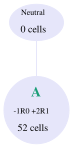

In [8]:

    
inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
inferred_tree.plot_tree(gene_labels=True, node_labels=True, tumor_type='breast', node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

#tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
#Render the tree plot using graphviz's render method

# inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
# # print(f"Tree plot saved to {tree_plot_filename}.png")

